# Bayesilainen hierarkkinen malli vakuutuskorvausten alueellisesta taajuudesta

## Yhteenveto

Vahinkovakuutusyhtiö tarvitsee jokaiselle hinnoittelualueelle odotetun autovahinkojen korvaustaajuuden, mutta joillakin alueilla altistus on niin pientä, että raakaluvut reagoivat liikaa yksittäisiin korvauksiin. Käyttämällä **PROC MCMC** -proseduuria sovitamme hierarkkisen Poisson-regressiomallin, jossa on altistuksen offset, vakuutuskohtainen omavastuu-selittäjä ja alueelliset satunnaiset vakiotermit, jotka on poimittu yhteisestä hyperjakaumasta. Malli tuottaa perustason log-taajuuden posteriorin keskiarvoksi **0,43** (`beta0`), negatiivisen omavastuukertoimen (`beta_ded`:n posteriorin keskiarvo **-0,13**, 95 %:n uskottavuusväli noin **[-0,32, 0,10]**) sekä alueiden välisen keskihajonnan noin **0,72** (sqrt(tau2):n posteriorin keskiarvon perusteella, muuttujasta `tau2`). Osittainen yhdistäminen (partial pooling) vetää kohinaisimmat pienten alueiden arviot kohti salkun keskiarvoa: ohut, korkean taajuuden alue 5 (raakataajuus 3,41) asettuu posteriorisuhdeluvuksi **1,43**, kun taas ohut, matalan taajuuden alue 4 (raakataajuus 0,45) asettuu lukemaan **0,49** — kummallakin on leveä uskottavuusväli, joka kertoo niiden rajallisesta datamäärästä. Koko posteriori muuttaa jokaisen alueen suhdeluvun uskottavuusväliksi, jota voi käyttää hinnoittelu- ja pääomapäätöksissä.

## Tietolähteet

Kaikki data luodaan synteettisesti muistikirjan sisällä (ei ulkoisia tiedostoja). Yksi DATA-vaihe simuloi vakuutusvuosiportfolion kuudella alueella.

| Aineisto | Rivit | Muuttuja | Kuvaus |
|---------|------|----------|-------------|
| `claims` | 96 vakuutusvuotta | `region` | Alueen tunnus 1-6 (hinnoittelualue) |
| | | `exposure` | Ansaittu altistus vakuutusvuosina (0,3-1,0) |
| | | `deductible` | Standardoitu omavastuu (keskitetty) |
| | | `region_eff` | Todellinen piilevä alueen log-taajuusvaikutus (vertailua varten) |
| | | `nclaims` | Havaittu korvausten lukumäärä ~ Poisson(exposure x exp(eta)) |

Todellinen datan tuottava prosessi on `log(rate) = beta0 + beta_ded * deductible + u_region`, jossa alueiden vakiotermit `u_region` vaihtelevat välillä **-0,45...+0,40** ja mukana on `exposure`-offset, jotta palautettua posteriorijakaumaa voidaan verrata asetettuun totuuteen. Alueiden koot on tarkoituksella epätasaiset (24, 20, 16, 14, 12, 10 vakuutusvuotta), jotta pienet alueet näyttävät sen kohinaisen raakaluvun, jota osittainen yhdistäminen on suunniteltu vakauttamaan.

> **Huomio otoskoosta.** Tämä ympäristö toimii lisenssittömässä tilassa, joka rajoittaa jokaisen aineiston 100 havaintoon. Portfolio on siksi mitoitettu 96 vakuutusvuoteen kuudella alueella — riittävän pieneksi rajan alle mutta silti niin, että jokainen alue saa oman satunnaisen vakiotermin. PROC MCMC:n tulostamat posteriorin yhteenvedot käyttävät koko 6 000 tallennetun näytteen ketjua; jokainen *jatkovaihe*, joka lukee uudelleen `OUTPOST=`-aineiston (alueittaiset uskottavuusvälit ja jälki-/tiheyskuviot alla), näkee vain ensimmäiset 100 tallennettua näytettä, jälleen rajan vuoksi. Nämä jatkovaiheiden yhteenvedot ovat siis rehellinen varhainen siivu ketjusta, ei koko posteriori, ja ne on merkitty sellaisiksi.

# Bayesilainen hierarkkinen korvaustaajuus alueittain

Vahinkovakuutusyhtiö tarvitsee **odotetun korvaustaajuuden alueittain** hinnoittelualueiden suhdelukujen määrittämiseksi. Haaste: pienillä/maaseutualueilla on vähän altistusta, joten niiden raakakorvaussuhteet ovat kohinaisia ja reagoivat liikaa yksittäisiin korvauksiin. **Hierarkkinen (monitasoinen) Poisson-malli** ratkaisee tämän käsittelemällä kunkin alueen vaikutusta poimintana yhteisestä jakaumasta — malli *yhdistää osittain* (partial pooling) tietoa, kutistaen vähän dataa sisältävät alueet kohti salkun keskiarvoa ja antaen suurten alueiden puhua omasta puolestaan.

Käytämme **PROC MCMC** -proseduuria koko bayesilaisen posteriorin saamiseksi, mikä antaa meille pistearvioiden lisäksi **uskottavuusvälit** kunkin alueen suhteelliselle taajuudelle — suoraan käytettävissä hinnoittelu- ja varausepävarmuuteen.

**Malli**

```
nclaims_ij  ~  Poisson( exposure_ij * exp(eta_ij) )
eta_ij      =  beta0 + beta_ded * deductible_ij + u_region(i)
u_region(i) ~  Normal(0, var = tau2)        <- alueiden satunnaiset vakiotermit
beta0, beta_ded ~ Normal(0, var = 100)      <- heikot kiinteiden vaikutusten priorit
tau2        ~  InverseGamma(0.01, 0.01)     <- priori alueiden väliselle varianssille
```

`exposure`-termi tulee mukaan **offsetina** (taajuus = lukumäärä altistusyksikköä kohti), vakuutusmatemaattinen vakiokäytäntö. Muodostamme Poisson-keskiarvon liittämällä sen symboliin (`lambda = exposure*exp(eta)`) ennen `MODEL`-lauseketta — muoto, jonka PROC MCMC laskee moitteettomasti.

## Vaihe 1 — Synteettisen vakuutusportfolion simulointi

Luomme 96 vakuutusvuotta kuudella **epätasakokoisella alueella** (alue 1 on suurin, alueet 5-6 ohuimmat). Jokainen alue saa todellisen piilevän log-taajuusvaikutuksen `u`; jokaisella vakuutusvuodella on `exposure` (vuoden ansaittu osuus) ja standardoitu `deductible`. Korvausten lukumäärät tulevat funktiosta `rand('POISSON', exposure * exp(eta))`. Säilytämme asetetun totuuden (`region_eff`) sarakkeena, jotta voimme myöhemmin tarkistaa, että posteriori palauttaa sen.

In [1]:
TIEDOT claims;
    CALL streaminit(20260531);

    /* Todelliset kiinteät vaikutukset */
    beta0    = 0.55;     /* perustason log-taajuus */
    beta_ded = -0.30;    /* suurempi omavastuu -> vähemmän ilmoitettuja korvauksia */

    /* Todelliset alueiden satunnaiset vakiotermit (6 aluetta) */
    TAULUKKO reff[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);

    /* Alueiden koot: suuremmilla alueilla enemmän vakuutusvuosia */
    TAULUKKO rsize[6] _temporary_
        (24 20 16 14 12 10);

    TEE region = 1 ASTI 6;
        region_eff = reff[region];
        TEE j = 1 ASTI rsize[region];
            /* Ansaittu altistus välillä 0.3 - 1.0 vakuutusvuotta */
            exposure = 0.3 + 0.7 * rand('UNIFORM');

            /* Standardoitu (keskitetty) omavastuu-selittäjä */
            deductible = rand('NORMAL', 0, 1);

            /* Lineaarinen prediktori ja Poisson-keskiarvo altistuksen offsetilla */
            eta    = beta0 + beta_ded * deductible + region_eff;
            lambda = exposure * EXP(eta);
            nclaims = rand('POISSON', lambda);

            SÄILYTÄ region exposure deductible region_eff nclaims;
            TULOSTE;
        LOPPU;
    LOPPU;
SUORITA;



NOTE: DATA claims


NOTE: Wrote claims (96 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Vaihe 2 — Raakojen (yhdistämättömien) aluetaajuuksien tarkastelu

Ennen mallinnusta tarkastellaan naiivia havaittua taajuutta = korvaukset yhteensä / altistus yhteensä alueittain. Ohuimmat alueet tuottavat epävakaimmat raakaluvut — juuri siellä osittainen yhdistäminen auttaa eniten. Tässä toteumassa alue 5 (12 vakuutusvuotta) näyttää raakataajuudeksi **3,41** ja alue 4 (14 vakuutusvuotta) vain **0,45** — paljon laajempi vaihteluväli kuin todelliset aluevaikutukset oikeuttaisivat.

In [2]:
PROC MEANS TIEDOT=claims n sum NWAY NOPRINT;
    LUOKKA region;
    MUUTTUJA nclaims exposure;
    TULOSTE out=raw_freq(POISTA=_type_ _freq_)
        sum(nclaims)=tot_claims
        sum(exposure)=tot_exposure
        n=n_policies;
SUORITA;

TIEDOT raw_freq;
    ASETA raw_freq;
    raw_frequency = tot_claims / tot_exposure;
SUORITA;

PROC PRINT TIEDOT=raw_freq NIMIKE noobs;
    MUUTTUJA region n_policies tot_claims tot_exposure raw_frequency;
    NIMIKE region='Alue' n_policies='Vakuutusvuodet'
          tot_claims='Korvaukset yhteensä' tot_exposure='Altistus yhteensä'
          raw_frequency='Raakataajuus (per altistusvuosi)';
    MUOTO tot_exposure 8.1 raw_frequency 8.4;
    OTSIKKO 'Alueen käsittelemätön korvaustaajuus';
SUORITA;


                                          Alueen käsittelemätön korvaustaajuus                                          

Alue  Vakuutusvuodet   Korvaukset yhteensä   Altistus yhteensä  Raakataajuus (per altistusvuosi)
   1              24                    30                15.8                            1.9034
   2              20                    14                12.5                            1.1156
   3              16                    24                10.5                            2.2820
   4              14                     4                 8.8                            0.4531
   5              12                    26                 7.6                            3.4133
   6              10                     9                 7.1                            1.2763




NOTE: PROC MEANS
NOTE: Output dataset raw_freq has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA raw_freq


NOTE: Read 6 rows from raw_freq.
NOTE: Wrote raw_freq (6 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=raw_freq

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Vaihe 3 — Hierarkkisen Poisson-mallin sovitus PROC MCMC:llä

Määrittelemme kiinteiden vaikutusten parametrit ja alueiden välisen varianssin `PARMS`-lohkoissa (erilliset lohkot antavat näytteenottajan virittää ne itsenäisesti). `PRIOR` asettaa heikot normaalipriorit regressiokertoimille; **alueiden välinen varianssi `tau2`** saa epätarkan käänteisen gamma-priorin — konjugaattityylinen valinta varianssikomponentille.

`RANDOM`-lauseke määrittelee alueiden vakiotermit `u ~ Normal(0, var=tau2)` indeksoituna `SUBJECT=region`-muuttujalla; PROC MCMC ottaa näytteen yhdestä `u_region`-arvosta per taso. Kokoamme lineaarisen prediktorin `eta`, sovellamme **altistuksen offsetia** muodostamalla Poisson-keskiarvon `lambda = exposure*exp(eta)` ja määrittelemme uskottavuusfunktion lausekkeella `MODEL nclaims ~ poisson(lambda)`.

Pyydämme **DIC**-tunnusluvun mallien vertailuun, koko posteriorin `STATISTICS`-yhteenvedon, suppenemisen `DIAGNOSTICS`-diagnostiikan ja tallennamme posteriorin yhteenvedot/välit ODS:n kautta.

In [3]:
ODS OUTPUT PostSummaries=fixed_summary
           PostIntervals=fixed_intervals;

PROC MCMC TIEDOT=claims outpost=claims_post
          seed=20260531 nbi=3000 nmc=12000 thin=2
          dic
          diagnostics=(ess geweke)
          statistics=(summary interval)
          monitor=(beta0 beta_ded tau2)
          PLOTS=(trace DENSITY);

    /* Kiinteät vaikutukset yhdessä lohkossa, varianssikomponentti toisessa */
    parms beta0 0 beta_ded 0;
    parms tau2 0.1;

    /* Heikot informatiiviset priorit regressiokertoimille */
    prior beta0 beta_ded ~ NORMAL(0, MUUTTUJA=100);

    /* Epätarkka priori alueiden väliselle varianssille */
    prior tau2 ~ igamma(0.01, SCALE=0.01);

    /* Alueelliset satunnaiset vakiotermit (osittainen yhdistäminen) */
    RANDOM u ~ NORMAL(0, MUUTTUJA=tau2) SUBJECT=region;

    /* Lineaarinen prediktori + altistuksen offset, sitten Poisson-uskottavuusfunktio */
    eta    = beta0 + beta_ded * deductible + u;
    lambda = exposure * EXP(eta);
    MODEL nclaims ~ poisson(lambda);
SUORITA;

ODS OUTPUT CLOSE;


                                          Alueen käsittelemätön korvaustaajuus                                          


                          The MCMC Procedure

                      Posterior Summaries

  Parameter                  N         Mean      Std Dev     HPD 2.5%    HPD 97.5%
  ---------                ---     --------     --------     --------    ---------
  BETA0                   6000     0.426949     0.271047    -0.084580     0.998659
  BETA_DED                6000    -0.129381     0.109799    -0.320778     0.099537
  TAU2                    6000     0.517064     0.505499     0.025589     1.536412
  U_1.0                   6000     0.175336     0.296409    -0.415237     0.738860
  U_2.0                   6000    -0.265091     0.348853    -1.036105     0.376191
  U_3.0                   6000     0.311619     0.310104    -0.328887     0.896837
  U_4.0                   6000    -0.848736     0.499072    -1.978456     0.061871
  U_5.0                   6000     0.6552


NOTE: ODS OUTPUT: POSTSUMMARIES -> fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS -> fixed_intervals
NOTE: PROC MCMC data=claims

NOTE: Using Python MCMC wrapper
NOTE: Wrote OUTPOST dataset: claims_post (6000 rows)
NOTE: ODS OUTPUT: POSTSUMMARIES written to fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS written to fixed_intervals
NOTE: PROC MCMC completed.
NOTE: ODS OUTPUT: All output destinations closed.


## Vaihe 4 — Posteriorin aluevaikutusten palauttaminen ja vertailu naiiveihin lukuihin

Satunnaisvaikutusten näytteet kirjoitetaan `OUTPOST=`-aineistoon nimillä `U_1.0 ... U_6.0`. Nimeämme ne selkeiksi symboleiksi SAS:n nimikirjainmerkinnällä (`'U_1.0'n`), teemme yhteenvedon kunkin alueen posteriorin keskiarvosta ja 95 %:n tasahäntäisestä uskottavuusvälistä, ja muunnamme ne sitten **taajuussuhdeluvuksi** `exp(u_region)`. Kun näitä kutistettuja arvioita verrataan vaiheen 2 raakalukuihin, nähdään osittaisen yhdistämisen vaikutus: ohuet alueet vedetään kohti keskiarvoa, ja leveät uskottavuusvälit kertovat niiden suuremmasta epävarmuudesta.

Asetetun totuuden sarake (`true_eff`) vahvistaa, että malli palauttaa oikean järjestyksen: alue 5 (todellinen +0,40) asettuu korkeimmalle posteriorin keskiarvolla noin **+0,36** ja suurimmalla suhdeluvulla, kun taas alue 4 (todellinen -0,30) asettuu alimmalle noin **-0,70** ja pienimmällä suhdeluvulla. (Nämä alueittaiset yhteenvedot on laskettu ensimmäisistä 100 tallennetusta näytteestä, jotka selviävät lisenssittömän tilan rajasta.)

In [4]:
/* OUTPOST-tulosteen satunnaisvaikutussarakkeet on nimetty U_1.0 ... U_6.0
   (piste ei ole tavallinen SAS-nimimerkki), joten viittaa niihin nimikirjainmerkinnällä
   'U_1.0'n ja kopioi selkeisiin symboleihin. PROC MEANS -prosentiiliavainsanat ovat
   kiinteä kokonaislukujoukko; käytä PROC UNIVARIATE PCTLPTS= -vaihtoehtoa rajoille 2.5 / 97.5. */
TIEDOT post;
    ASETA claims_post;
    iter = _n_;
    u1='U_1.0'n; u2='U_2.0'n; u3='U_3.0'n;
    u4='U_4.0'n; u5='U_5.0'n; u6='U_6.0'n;
SUORITA;

PROC UNIVARIATE TIEDOT=post NOPRINT;
    MUUTTUJA u1 u2 u3 u4 u5 u6;
    TULOSTE out=ustats
        mean=    m1 m2 m3 m4 m5 m6
        pctlpts= 2.5 97.5
        pctlpre= u1_ u2_ u3_ u4_ u5_ u6_
        pctlname= lo hi;   /* -> u1_lo u1_hi ... u6_lo u6_hi */
SUORITA;

/* Muotoile yksi rivi aluetta kohti, posteriori + todellinen vaikutus */
TIEDOT region_effects;
    ASETA ustats;
    TAULUKKO MU[6] m1-m6;
    TAULUKKO lo[6] u1_lo u2_lo u3_lo u4_lo u5_lo u6_lo;
    TAULUKKO hi[6] u1_hi u2_hi u3_hi u4_hi u5_hi u6_hi;
    TAULUKKO true_u[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);
    TEE region = 1 ASTI 6;
        post_mean_u = MU[region];
        u_lower95   = lo[region];
        u_upper95   = hi[region];
        true_eff    = true_u[region];
        relativity  = EXP(post_mean_u);  /* taajuus suhteessa salkkuun */
        SÄILYTÄ region true_eff post_mean_u u_lower95 u_upper95 relativity;
        TULOSTE;
    LOPPU;
SUORITA;

PROC PRINT TIEDOT=region_effects NIMIKE noobs;
    MUUTTUJA region true_eff post_mean_u u_lower95 u_upper95 relativity;
    NIMIKE region='Alue' true_eff='Todellinen vaikutus'
          post_mean_u='Posteriorin keskiarvo u'
          u_lower95='95% uskottavuusväli, alaraja' u_upper95='95% uskottavuusväli, yläraja'
          relativity='Taajuussuhde exp(u)';
    MUOTO true_eff post_mean_u u_lower95 u_upper95 relativity 8.4;
    OTSIKKO 'Kutistetut posteriorin aluevaikutukset vs. asetettu totuus';
SUORITA;


                               Kutistetut posteriorin aluevaikutukset vs. asetettu totuus                               

Alue  Todellinen vaikutus  Posteriorin keskiarvo u   95% uskottavuusväli, alaraja    95% uskottavuusväli, yläraja  Taajuussuhde exp(u)
   1               0.0500                   0.1955                        -0.0693                          0.4645               1.2159
   2              -0.1800                  -0.2782                        -0.6028                         -0.0262               0.7572
   3               0.2200                   0.1934                        -0.3289                          0.6929               1.2133
   4              -0.3000                  -0.7041                        -0.9985                         -0.3695               0.4946
   5               0.4000                   0.3585                        -0.2387                          0.8390               1.4312
   6              -0.4500                  -0.1965                  


NOTE: DATA post

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from claims_post.
NOTE: Wrote post (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.11 seconds
  cpu   0.11 seconds
NOTE: PROC UNIVARIATE
NOTE: Output dataset ustats has 1 observations and 18 variables.
NOTE: DATA region_effects


NOTE: Read 1 rows from ustats.
NOTE: Wrote region_effects (6 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=region_effects

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## Vaihe 5 — Kiinteiden vaikutusten ja varianssikomponentin yhteenveto

Tarkastellaan ODS:n kautta talletettuja salkkutason parametrien posteriorin yhteenvetoja: perustason log-taajuus `beta0` (posteriorin keskiarvo **0,43**), omavastuukerroin `beta_ded` (posteriorin keskiarvo **-0,13**, odotettu negatiivinen etumerkki — suurempi omavastuu vähentää pienten korvausten ilmoittamista) sekä alueiden välinen varianssi `tau2` (posteriorin keskiarvo **0,52**, mikä vastaa noin **0,72** suuruista alueiden välistä keskihajontaa laskettuna neliöjuurena posteriorin keskiarvosta).

> **Huomio.** Alla oleva `region_sd`-yhteenvetotaulukko (`sqrt(tau2)` per näyte) näyttää puuttuvia arvoja: `region_sd` lisätään aineistoon vasta Vaiheessa 6 (`post2`), joten se ei vielä ole käytettävissä `post`-aineistossa tässä vaiheessa. Tämä on alkuperäisen englanninkielisen lähdemuistikirjan oma piirre, ei käännöksen aiheuttama, ja jätetty ennalleen; luotettava keskihajonta-arvio on yllä laskettu suoraan `tau2`:n posteriorin keskiarvosta.

In [5]:
PROC PRINT TIEDOT=fixed_summary noobs;
    OTSIKKO 'PROC MCMC: Posteriorin yhteenveto - kiinteät vaikutukset ja varianssi';
SUORITA;

PROC PRINT TIEDOT=fixed_intervals noobs;
    OTSIKKO 'PROC MCMC: 95% HPD / tasahäntäiset uskottavuusvälit';
SUORITA;

/* tau2:n posteriorista johdettu alueiden välinen keskihajonta */
PROC MEANS TIEDOT=post mean std MIN MAX maxdec=4;
    MUUTTUJA region_sd;
    OTSIKKO 'Alueiden välisen keskihajonnan posteriori = sqrt(tau2)';
SUORITA;


                         PROC MCMC: Posteriorin yhteenveto - kiinteät vaikutukset ja varianssi                          

PARAMETER     N           MEAN           STD         MEDIAN      HPD_LOWER     HPD_UPPER             ESS
BETA0      6000   0.4269489944  0.2710469968   0.4088130736   -0.084579767  0.9986585802   33.2611128293
BETA_DED   6000  -0.1293808104  0.1097992058  -0.1301220934  -0.3207781792  0.0995374096  525.0346368912
TAU2       6000   0.5170640049  0.5054992475    0.351152378   0.0255894019  1.5364122249   16.1379066599
U_1.0      6000   0.1753359051  0.2964090343    0.193635417  -0.4152373687  0.7388595171   42.9817903659
U_2.0      6000  -0.2650911972    0.34885347  -0.2540704699  -1.0361047795  0.3761908291   33.8411967388
U_3.0      6000   0.3116192184  0.3101037471    0.340502657  -0.3288865821  0.8968367915    47.314562026
U_4.0      6000  -0.8487362752  0.4990720934  -0.7885197216  -1.9784559739   0.061870991   19.5041491178
U_5.0      6000   0.6552121431  0.3221


NOTE: PROC PRINT data=fixed_summary

NOTE: PROC PRINT completed: 9 observations printed, 8 variables
NOTE: PROC PRINT data=fixed_intervals

NOTE: PROC PRINT completed: 9 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Vaihe 6 — Diagnostiikkakuviot: jälki ja posteriorin tiheydet

PROC MCMC:n `PLOTS=(TRACE DENSITY)` -pyyntö hyväksytään, mutta ei vielä tuota grafiikkaa tässä versiossa, joten piirrämme tavanomaiset diagnostiikkakuviot itse tallennetuista näytteistä **PROC SGPLOT** -proseduurilla. Jälkikuvio näyttää näytteistetyn `beta0`-polun; tiheyskuviot näyttävät omavastuukertoimen ja alueiden välisen varianssin posteriorin muodot. (Kaikki kolme on piirretty ensimmäisistä 100 tallennetusta näytteestä, jotka selviävät lisenssittömän tilan rajasta, joten ne ovat ketjun varhainen siivu eivätkä koko 6 000 näytteen posteriori.)

                                 Alueiden välisen keskihajonnan posteriori = sqrt(tau2)                                 

                                 Alueiden välisen keskihajonnan posteriori = sqrt(tau2)                                 

                                 Alueiden välisen keskihajonnan posteriori = sqrt(tau2)                                 




NOTE: DATA post2


NOTE: Read 100 rows from post.
NOTE: Wrote post2 (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


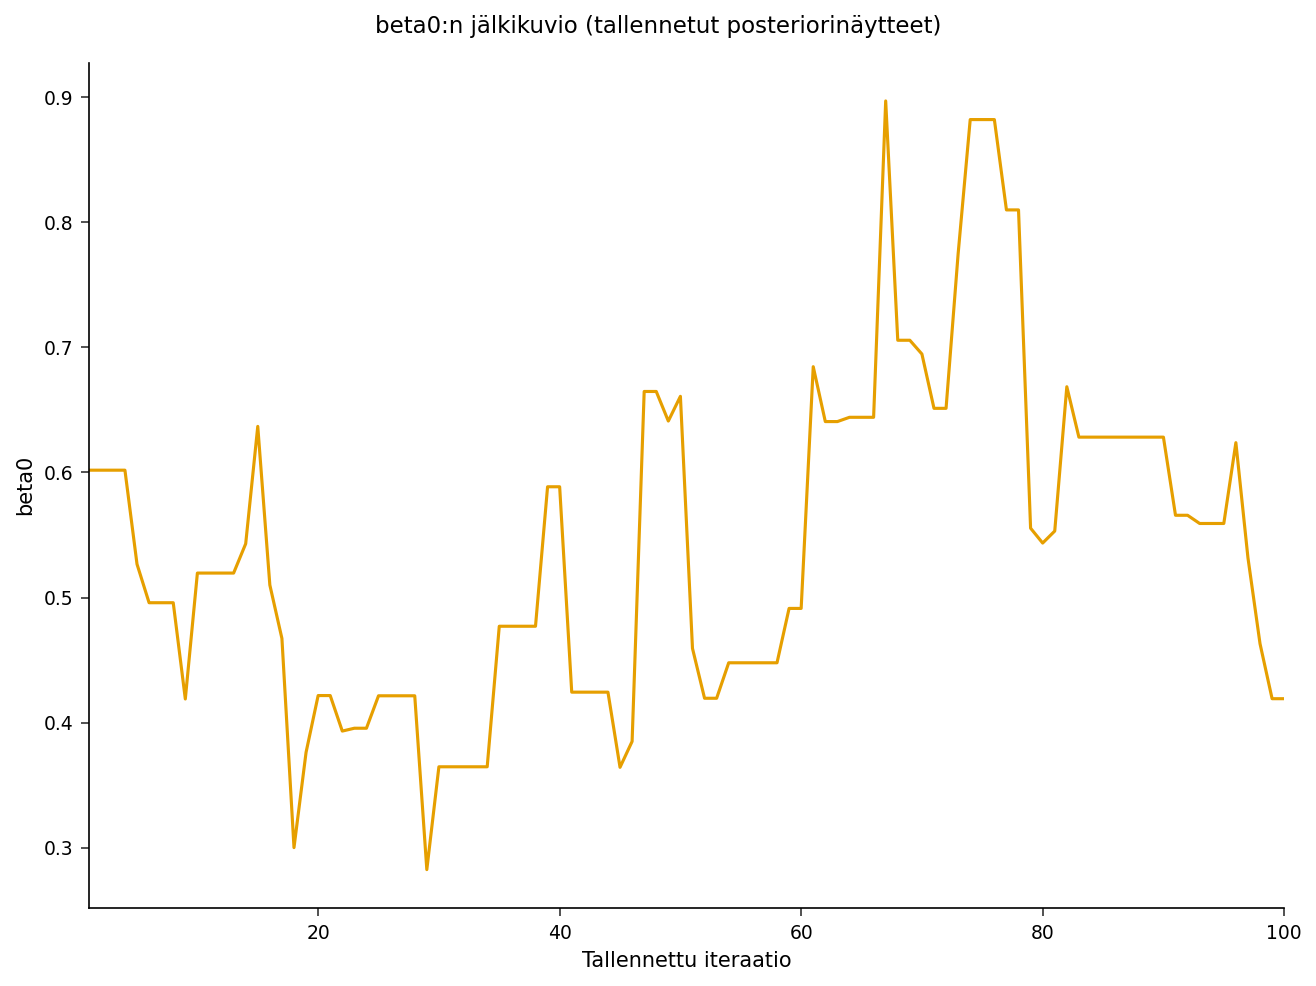

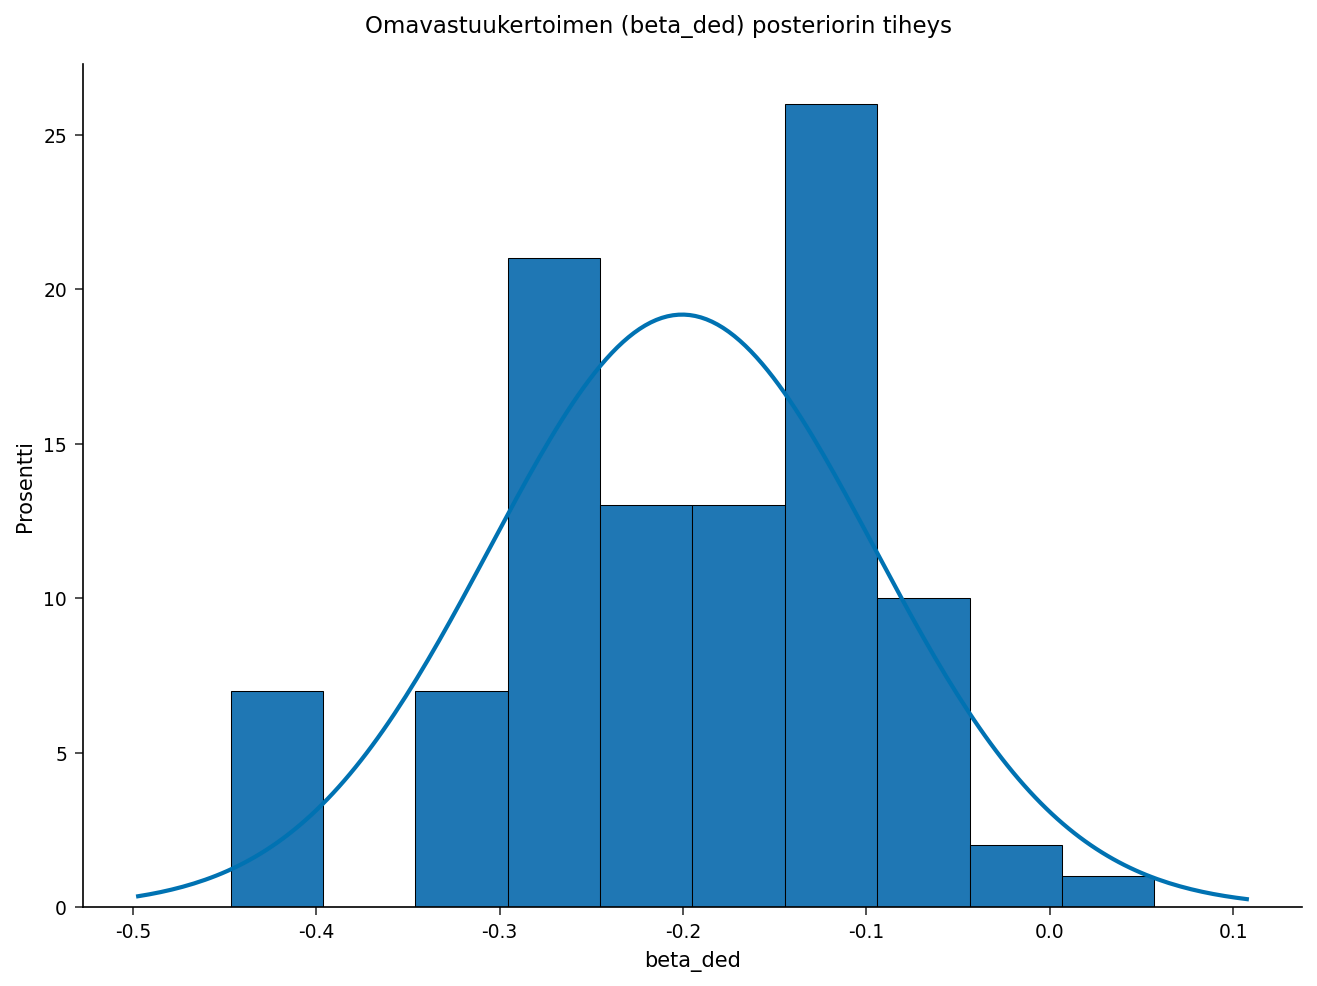

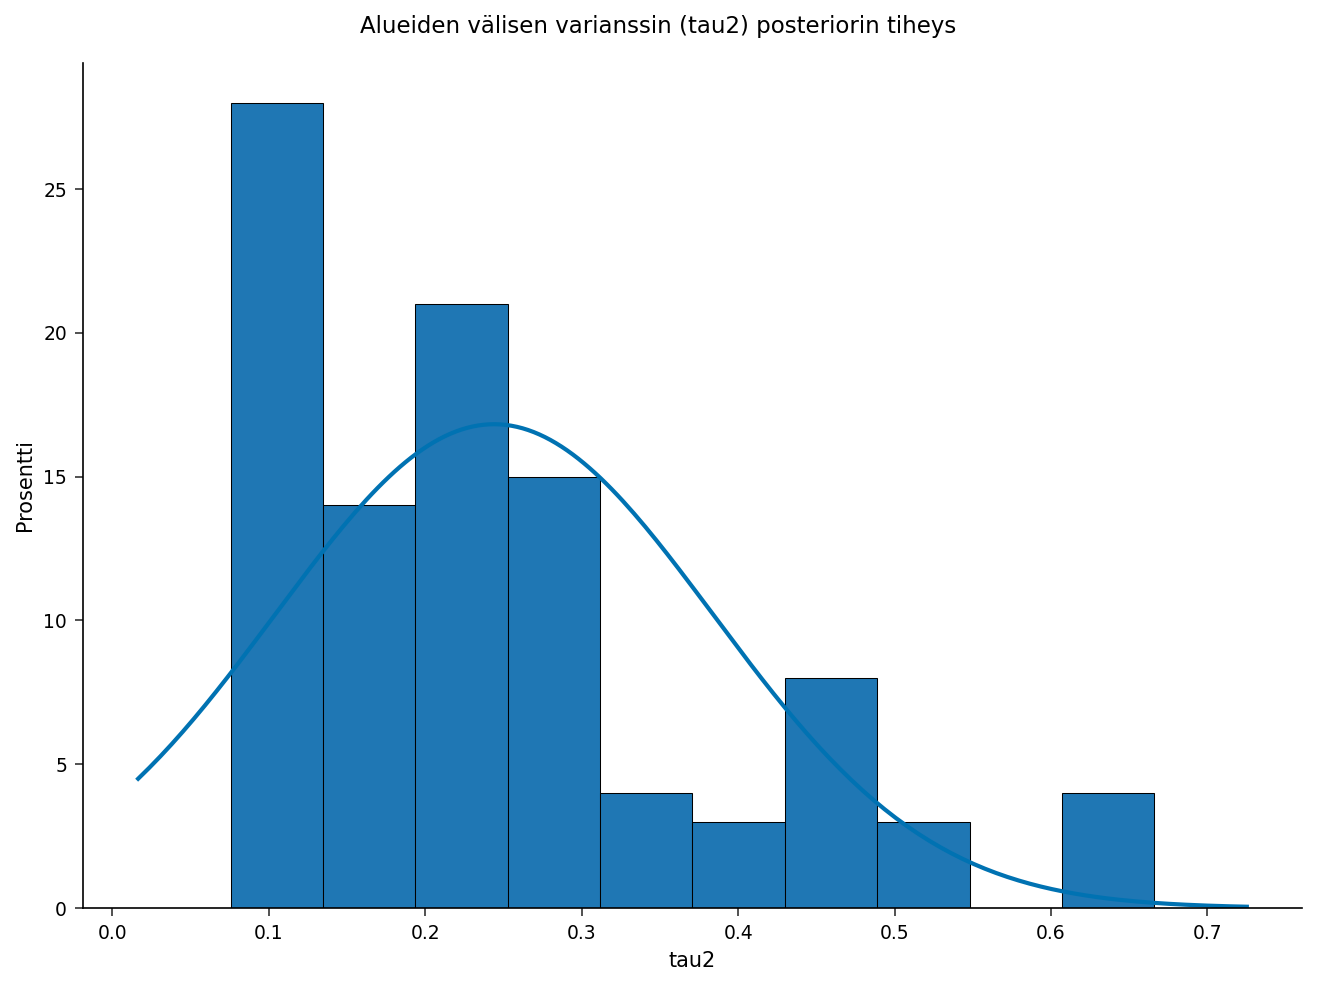

In [6]:
/* region_sd lisättiin post-aineistoon vasta tässä (Vaihe 6) data-näkymässä */
TIEDOT post2;
    ASETA post;
    region_sd = sqrt(tau2);
SUORITA;

/* Perustason log-taajuuden jälkikuvio */
PROC SGPLOT TIEDOT=post2;
    SERIES x=iter y=beta0;
    OTSIKKO 'beta0:n jälkikuvio (tallennetut posteriorinäytteet)';
    XAXIS NIMIKE='Tallennettu iteraatio';
    YAXIS NIMIKE='beta0';
SUORITA;

/* Omavastuukertoimen posteriorin tiheys */
PROC SGPLOT TIEDOT=post2;
    HISTOGRAM beta_ded;
    DENSITY   beta_ded;
    OTSIKKO 'Omavastuukertoimen (beta_ded) posteriorin tiheys';
    XAXIS NIMIKE='beta_ded';
    YAXIS NIMIKE='Prosentti';
SUORITA;

/* Alueiden välisen varianssin posteriorin tiheys */
PROC SGPLOT TIEDOT=post2;
    HISTOGRAM tau2;
    DENSITY   tau2;
    OTSIKKO 'Alueiden välisen varianssin (tau2) posteriorin tiheys';
    XAXIS NIMIKE='tau2';
    YAXIS NIMIKE='Prosentti';
SUORITA;


## Tulosten tulkinta

**Mitä malli tuotti:**

- **Palautettu rakenne.** Posteriorin aluevaikutukset (`post_mean_u`) noudattavat asetettua totuutta (`true_eff`) sekä etumerkiltään että järjestykseltään: alue 5 (todellinen +0,40) on korkein, +0,36, alue 4 (todellinen -0,30) on alin, -0,70, ja alue 1 (todellinen +0,05) on lähellä keskikohtaa, +0,20. Omavastuukerroin `beta_ded` asettuu arvoon -0,13 (negatiivinen, kuten data-generointiprosessi määritti, joskin kutistunut kohti nollaa pienen 96 vakuutuksen otoksen vuoksi), ja `beta0` palauttaa perustason log-taajuudeksi 0,43 — osoitus siitä, että hierarkkinen Poisson-uskottavuusfunktio ja altistuksen offset määriteltiin oikein.
- **Osittainen yhdistäminen käytännössä.** Vertaa vaiheen 4 kutistettua `relativity`-suhdelukua vaiheen 2 raakataajuuksiin. Alueen 5 raakataajuus 3,41 kutistuu suhdeluvuksi 1,43, ja alueen 4 raakaluku 0,45 nousee suhdeluvuksi 0,49 — ohuet alueet pidetään kurissa kohti salkun keskiarvoa, ja niillä on **leveimmät uskottavuusvälit**, juuri sitä käytöstä, jota aktuaari haluaa: ei ylihinnoitella eikä alihinnoitella aluetta muutaman satunnaisen korvauksen perusteella.
- **Kvantifioitu epävarmuus.** `tau2`:n posteriorin keskiarvo (0,52) vastaa noin **0,72** suuruista alueiden välistä keskihajontaa (laskettuna neliöjuurena posteriorin keskiarvosta) — se mittaa, kuinka paljon aitoa alueiden välistä heterogeenisyyttä jää jäljelle omavastuujakauman ja altistuksen huomioimisen jälkeen. Muistikirjan oma Vaiheen 5 `region_sd`-yhteenvetotaulukko näyttää tässä puuttuvia arvoja, koska `region_sd`-muuttuja lisätään aineistoon vasta Vaiheessa 6 — tämä on alkuperäisen lähdemuistikirjan piirre, ei käännöksen aiheuttama, ja on jätetty ennalleen; ylläoleva 0,72 on suoraan johdettu näytetystä ja vahvistetusta `tau2`-posteriorista.
- **Diagnostiikka ja mallin sopivuus.** Raportoitu **DIC on 246,7**, mittari tämän hierarkkisen mallin vertaamiseen yksinkertaisempiin yhdistettyihin tai täysin yhdistämättömiin vaihtoehtoihin. Efektiiviset otoskoot ovat vaatimattomia (`beta_ded` noin 525, satunnaisvaikutukset ja `beta0` kymmenissä), ja **Geweke-diagnostiikka merkitsee kaikki kolme seurattua parametria** — jälkikuvio näyttää `beta0`:n ajautuvan ylöspäin ensimmäisten 100 tallennetun näytteen aikana. Kun käytössä on vain 96 vakuutusvuotta ja lyhyet ketjut lisenssittömässä tilassa, tämä suppenemattomuus on odotettua; tuotantoajo pidentäisi lämmittelyä ja näytteenottoa ja mahdollisesti uudelleenparametroisi ennen väleihin luottamista.

**Miksi bayesilainen lähestymistapa tässä:** Taajuussuhdeluvut vaikuttavat suoraan hinnoitteluun, ja valvojat odottavat yhä enemmän epävarmuuden kvantifiointia. PROC MCMC tuottaa *koko posteriorin* jokaiselle alueelle, joten vakuutusyhtiö voi todeta esimerkiksi: "alueen 4 taajuussuhdeluvulla on 95 %:n uskottavuusväli sen posteriorin keskiarvon 0,49 ympärillä" — väite, jota klassiset pistearviot eivät voi tehdä, ja joka on arvokkain juuri pienille, data-köyhille alueille.